### 199.M. Binary Tree Right Side View

Given the root of a binary tree, imagine yourself standing on the right side of it, return the values of the nodes you can see ordered from top to bottom.

Example: 

    root = [1,2, 3, null, 5, null, 4]

    Output = [1, 3, 4]
    
Explanation: 
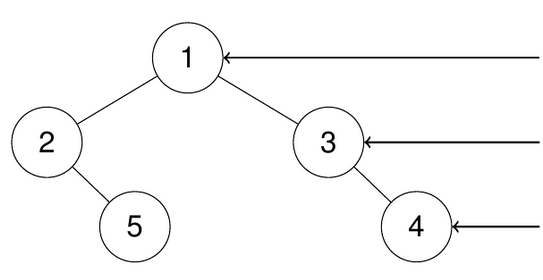


Approach - Iterative level order traversal

In [ ]:
from typing import Optional, List
from collections import deque

class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right
class Solution:
    def rightSideView(self, root: Optional[TreeNode]) -> List[int]:
        if not root:
            return []        
        result = []
        queue = deque([root])

        while queue:
            levelSize = len(queue)
            for i in range(levelSize):
                node = queue.popleft() 
                if i == levelSize - 1:
                    result.append(node.val)
                if node.left:
                    queue.append(node.left)
                if node.right:
                    queue.append(node.right)
        return result
    



### Approach: DFS (Right First) - Cleaner version 

Idea:
    - Traverse Right -> Left 
    - First node seen at each level is the "answer"

In [4]:
class TreeNode: 
    def __init__(self, x):
        self.val = x
        self.left = None 
        self.right = None 

class Solution:
    def rightSideView(self, root):
        result = [] 

        def dfs(node, depth):
            if not node: 
                return 

            # First node at this depth 
            if depth == len(result):
                result.append(node.val)

            dfs(node.right, depth + 1) 
            dfs(node.left, depth + 1)
        dfs(root, 0)
        return result

if __name__ == "__main__":
    sol = Solution() 

    # test case #1 
    root = None 
    print (sol.rightSideView(root))

    # Single Node Tree 
    root = TreeNode(1)
    print (sol.rightSideView(root))

    # Balanced Tree 
    #       1
    #      / \
    #     2   3
    #    / \   \
    #   4   5   6
    root = TreeNode(1)
    root.left = TreeNode(2)
    root.right = TreeNode(3)
    root.left.left = TreeNode(4)
    root.left.right = TreeNode(5)
    root.right.right = TreeNode(6)

    print(sol.rightSideView(root))  
    # Expected: [1, 3, 6]

    # Left-Skewed Tree
    #   1
    #  /
    # 2
    #  /
    # 3
    root = TreeNode(1)
    root.left = TreeNode(2)
    root.left.left = TreeNode(3)

    print(sol.rightSideView(root))  
    # Expected: [1, 2, 3]

    # Right-Skewed Tree
    # 1
    #  \
    #   2
    #    \
    #     3
    root = TreeNode(1)
    root.right = TreeNode(2)
    root.right.right = TreeNode(3)

    print(sol.rightSideView(root))  
    # Expected: [1, 2, 3]

    # Mixed Tree
    #       10
    #      /  \
    #     5    20
    #      \   /
    #       8 15
    root = TreeNode(10)
    root.left = TreeNode(5)
    root.right = TreeNode(20)
    root.left.right = TreeNode(8)
    root.right.left = TreeNode(15)

    print(sol.rightSideView(root))  
    # Expected: [10, 20, 15]

[]
[1]
[1, 3, 6]
[1, 2, 3]
[1, 2, 3]
[10, 20, 15]
